In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup aesthetic premium
sns.set_theme(style="whitegrid", palette="magma")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16

# Load data
df = pd.read_csv('../save/fertilizer_localized.csv')


In [2]:
print(df.info())
display(df.describe())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Soil_Type                    10000 non-null  str    
 1   Soil_pH                      10000 non-null  float64
 2   Soil_Moisture                10000 non-null  float64
 3   Organic_Carbon               10000 non-null  float64
 4   Electrical_Conductivity      10000 non-null  float64
 5   Nitrogen_Level               10000 non-null  int64  
 6   Phosphorus_Level             10000 non-null  int64  
 7   Potassium_Level              10000 non-null  int64  
 8   Temperature                  10000 non-null  float64
 9   Humidity                     10000 non-null  float64
 10  Rainfall                     10000 non-null  float64
 11  Crop_Type                    10000 non-null  str    
 12  Crop_Growth_Stage            10000 non-null  str    
 13  Season                      

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Fertilizer_Used_Last_Season,Yield_Last_Season
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.485728,35.411531,0.844731,1.543156,88.995000,48.965100,64.147000,25.058906,60.093727,1588.085798,176.165508,4.531666
std,1.152964,14.413002,0.372406,0.839514,40.336674,23.195588,31.867211,8.601550,17.386120,810.992404,72.235790,2.013522
min,4.500000,10.000000,0.200000,0.100000,20.000000,10.000000,10.000000,10.000000,30.010000,200.080000,50.010000,1.000000
25%,5.490000,23.030000,0.520000,0.820000,54.000000,29.000000,37.000000,17.580000,44.925000,874.780000,113.175000,2.780000
50%,6.460000,35.645000,0.850000,1.530000,89.000000,49.000000,64.000000,25.085000,60.345000,1594.295000,176.835000,4.550000
75%,7.490000,47.662500,1.160000,2.270000,124.000000,69.000000,92.000000,32.502500,75.420000,2283.782500,239.232500,6.260000
max,8.500000,60.000000,1.500000,3.000000,159.000000,89.000000,119.000000,40.000000,89.990000,2999.980000,300.000000,8.000000


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Rainy,Canal,Wheat,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Rainy,Sprinkler,Potato,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Rainy,Rainfed,Tomato,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Transition,Sprinkler,Potato,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Rainy,Rainfed,Maize,214.39,7.36,Zinc Sulphate


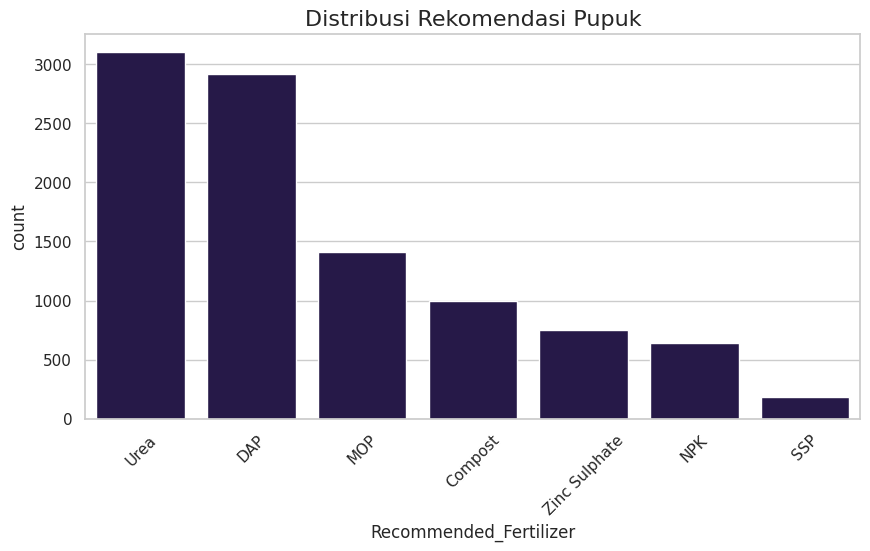

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Recommended_Fertilizer', order=df['Recommended_Fertilizer'].value_counts().index)
plt.title('Distribusi Rekomendasi Pupuk')
plt.xticks(rotation=45)
plt.show()

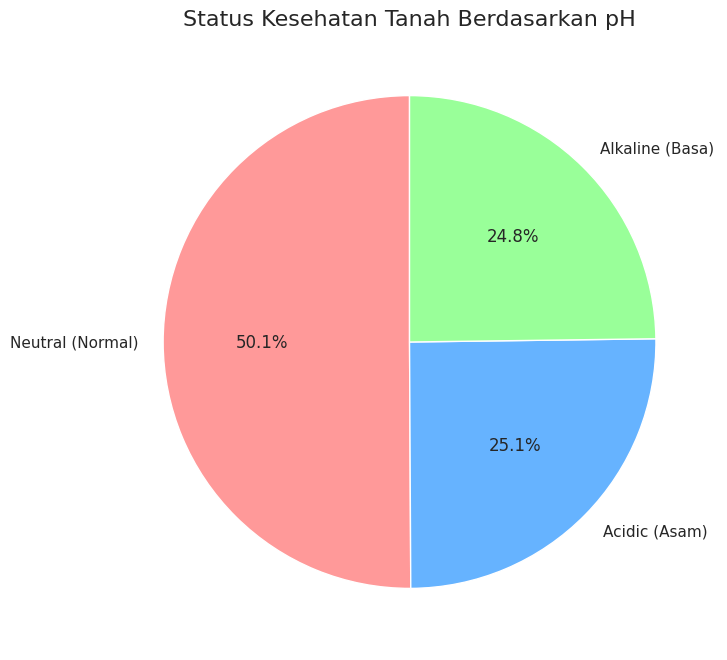

In [4]:
def classify_ph(ph):
    if ph < 5.5: return 'Acidic (Asam)'
    elif ph > 7.5: return 'Alkaline (Basa)'
    else: return 'Neutral (Normal)'

df['Soil_Health'] = df['Soil_pH'].apply(classify_ph)

plt.figure(figsize=(8, 8))
df['Soil_Health'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Status Kesehatan Tanah Berdasarkan pH')
plt.ylabel('')
plt.show()

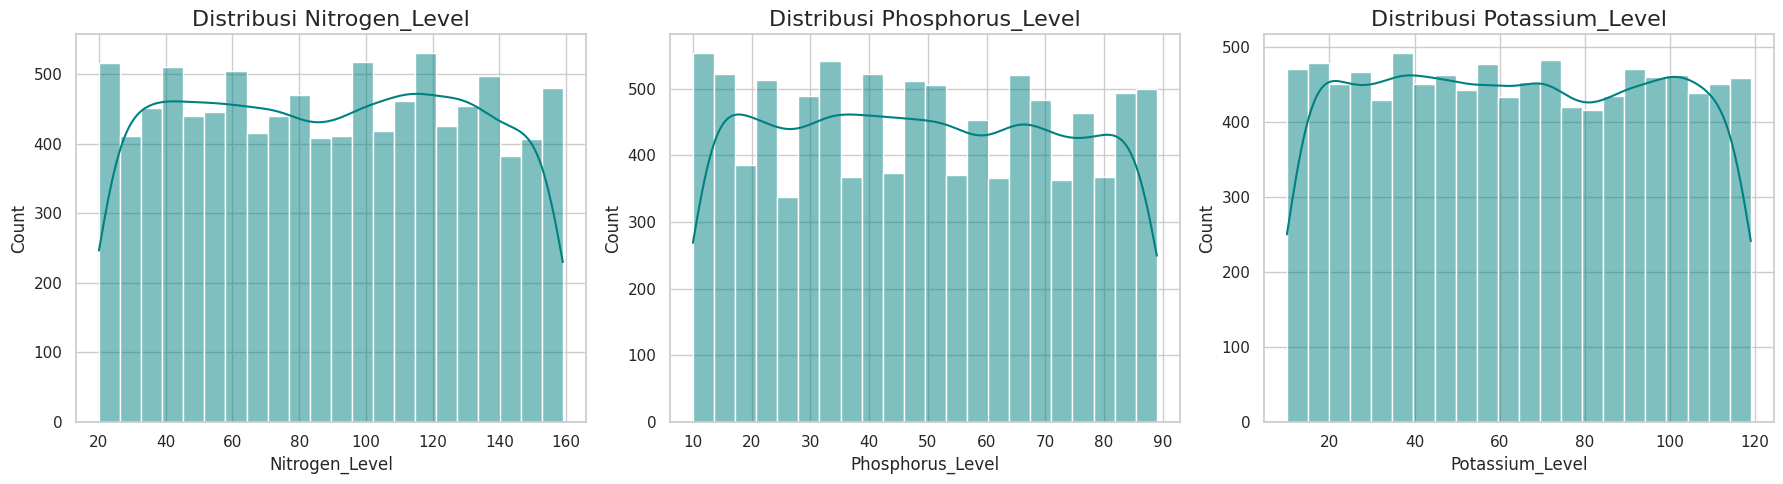

In [5]:
nutrients = ['Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(nutrients):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

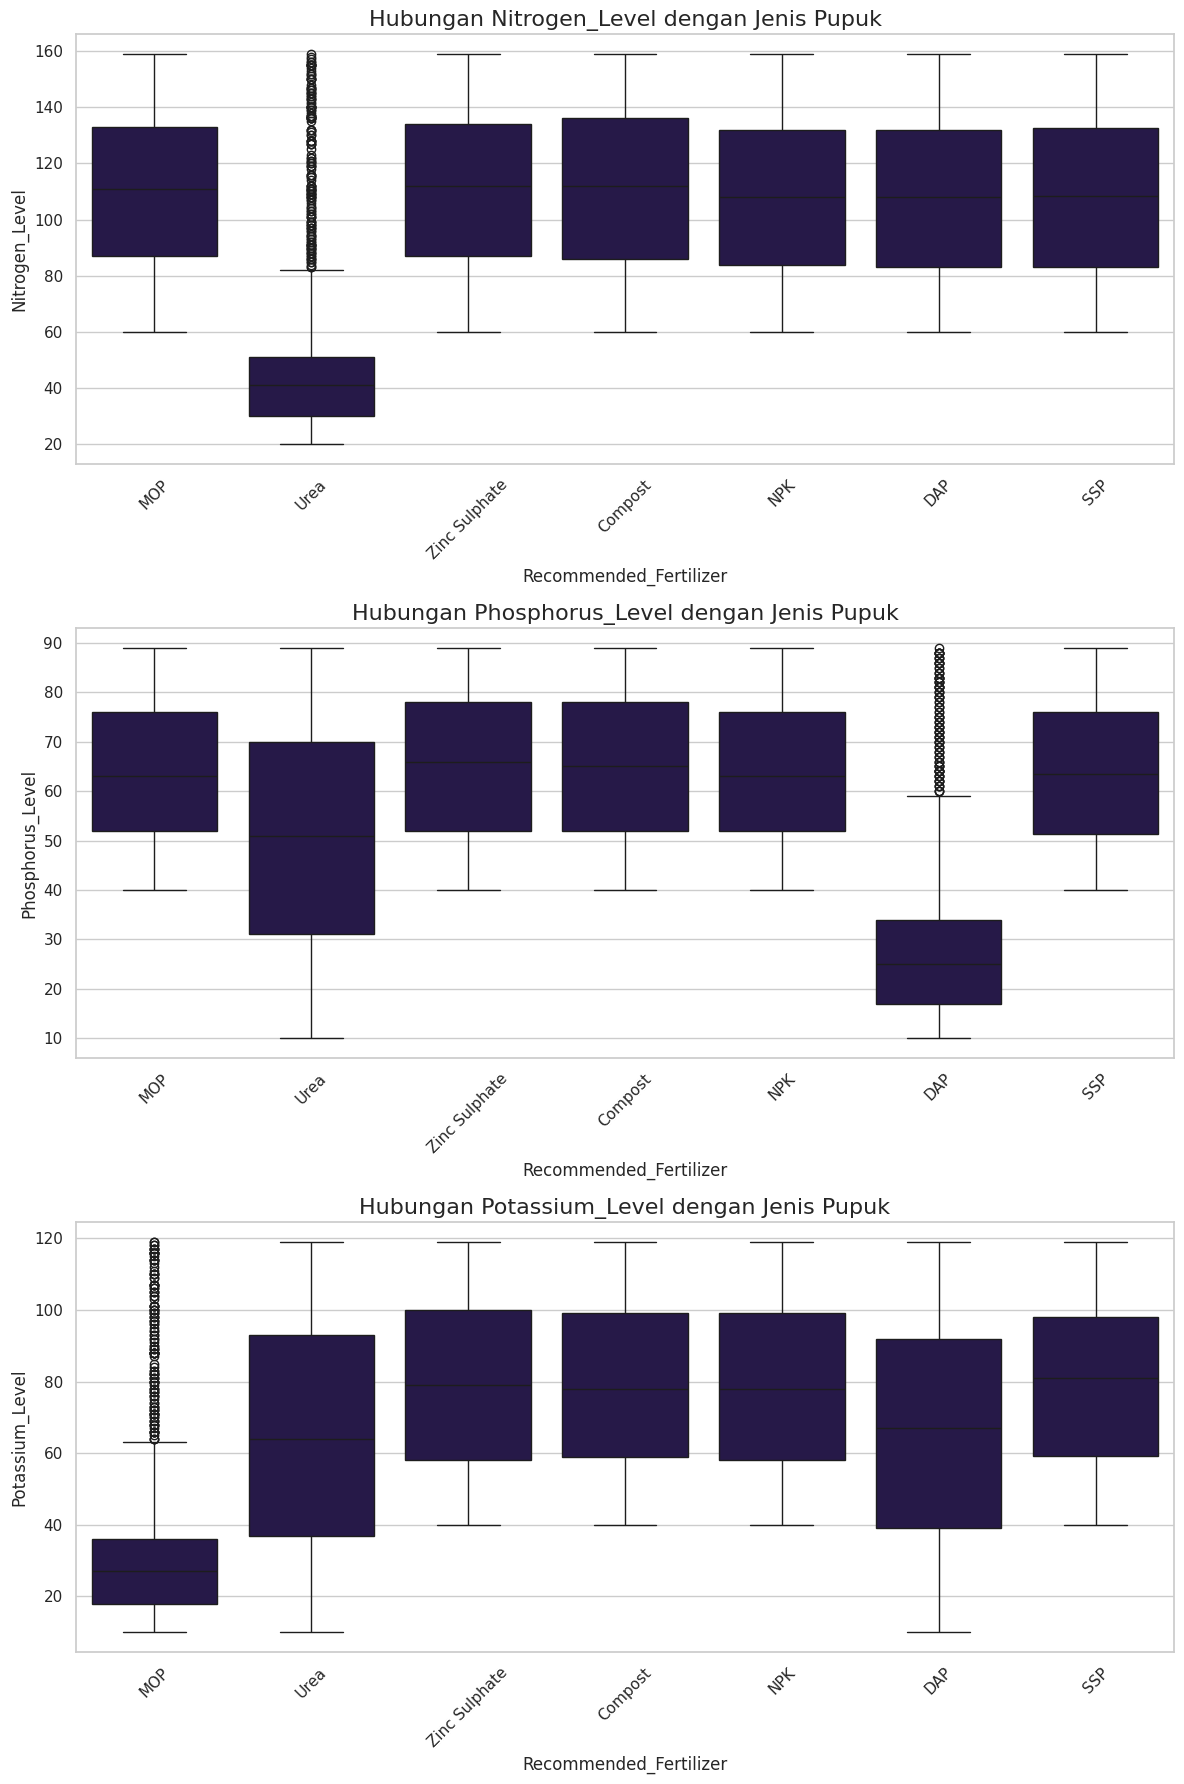

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for i, col in enumerate(nutrients):
    sns.boxplot(data=df, x='Recommended_Fertilizer', y=col, ax=axes[i])
    axes[i].set_title(f'Hubungan {col} dengan Jenis Pupuk')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

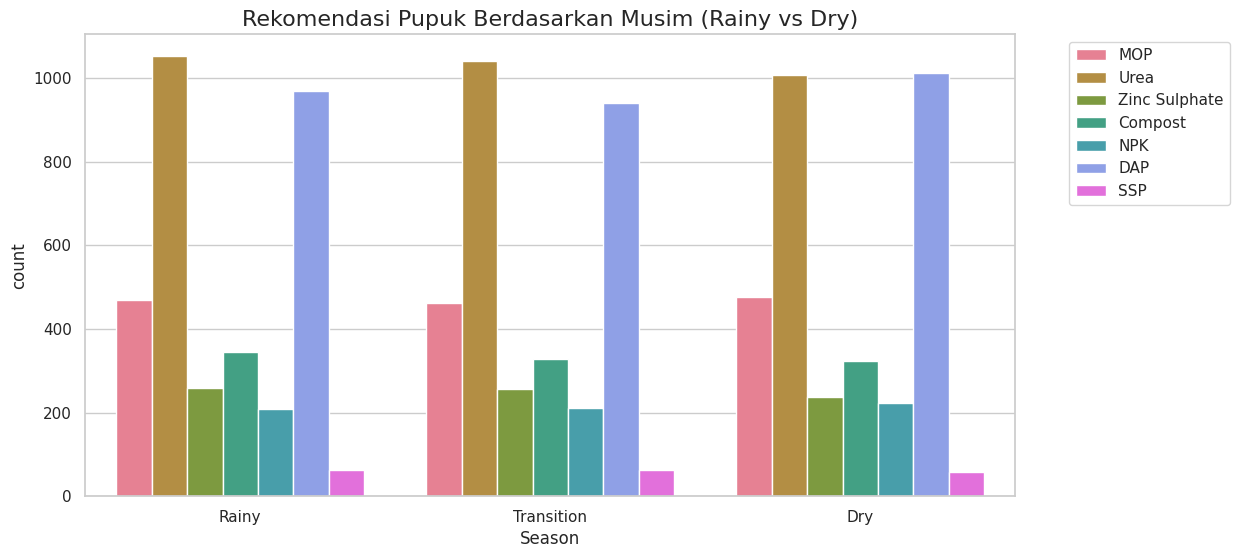

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Season', hue='Recommended_Fertilizer')
plt.title('Rekomendasi Pupuk Berdasarkan Musim (Rainy vs Dry)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

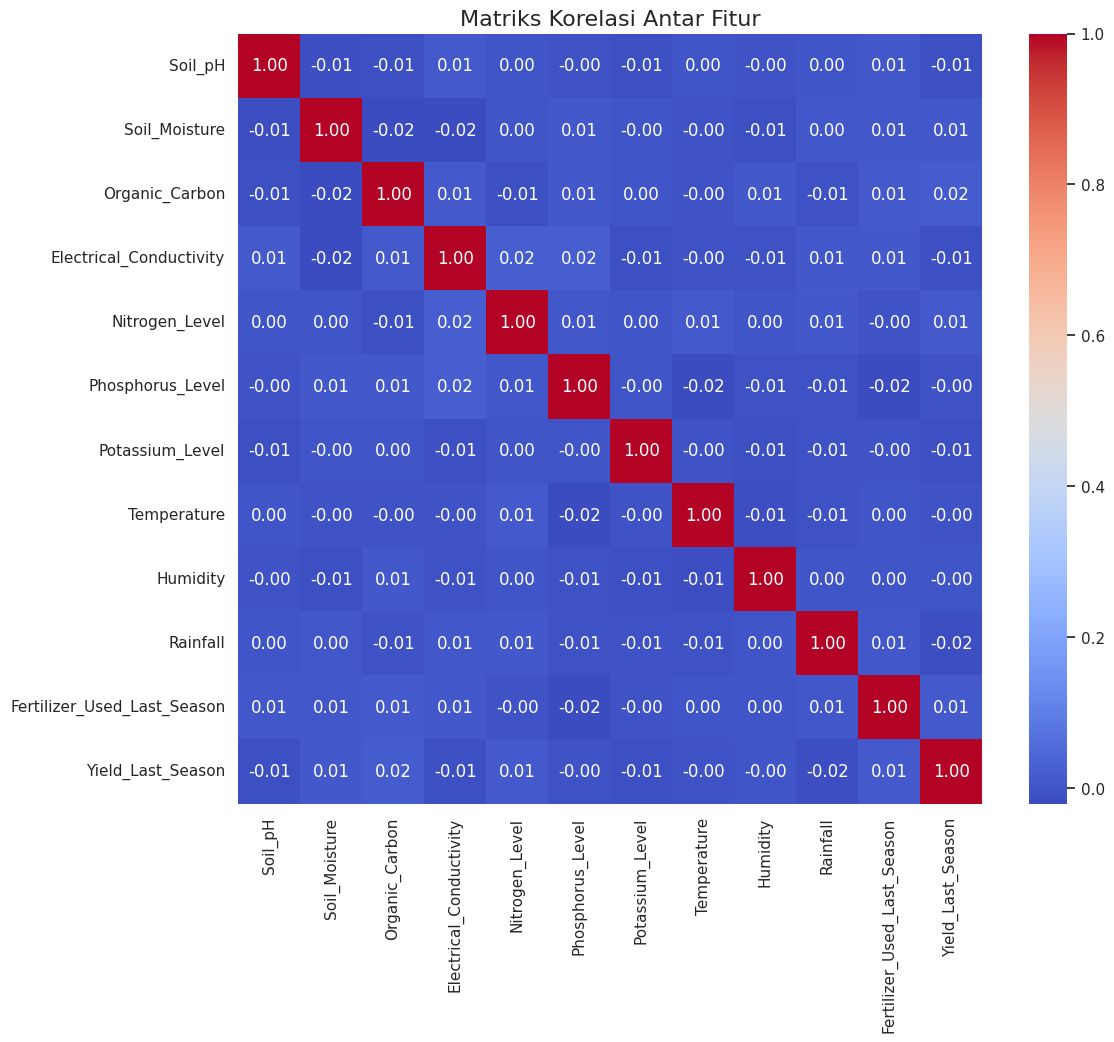

In [8]:
plt.figure(figsize=(12, 10))
# Mengambil kolom numerik saja
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Antar Fitur')
plt.show()

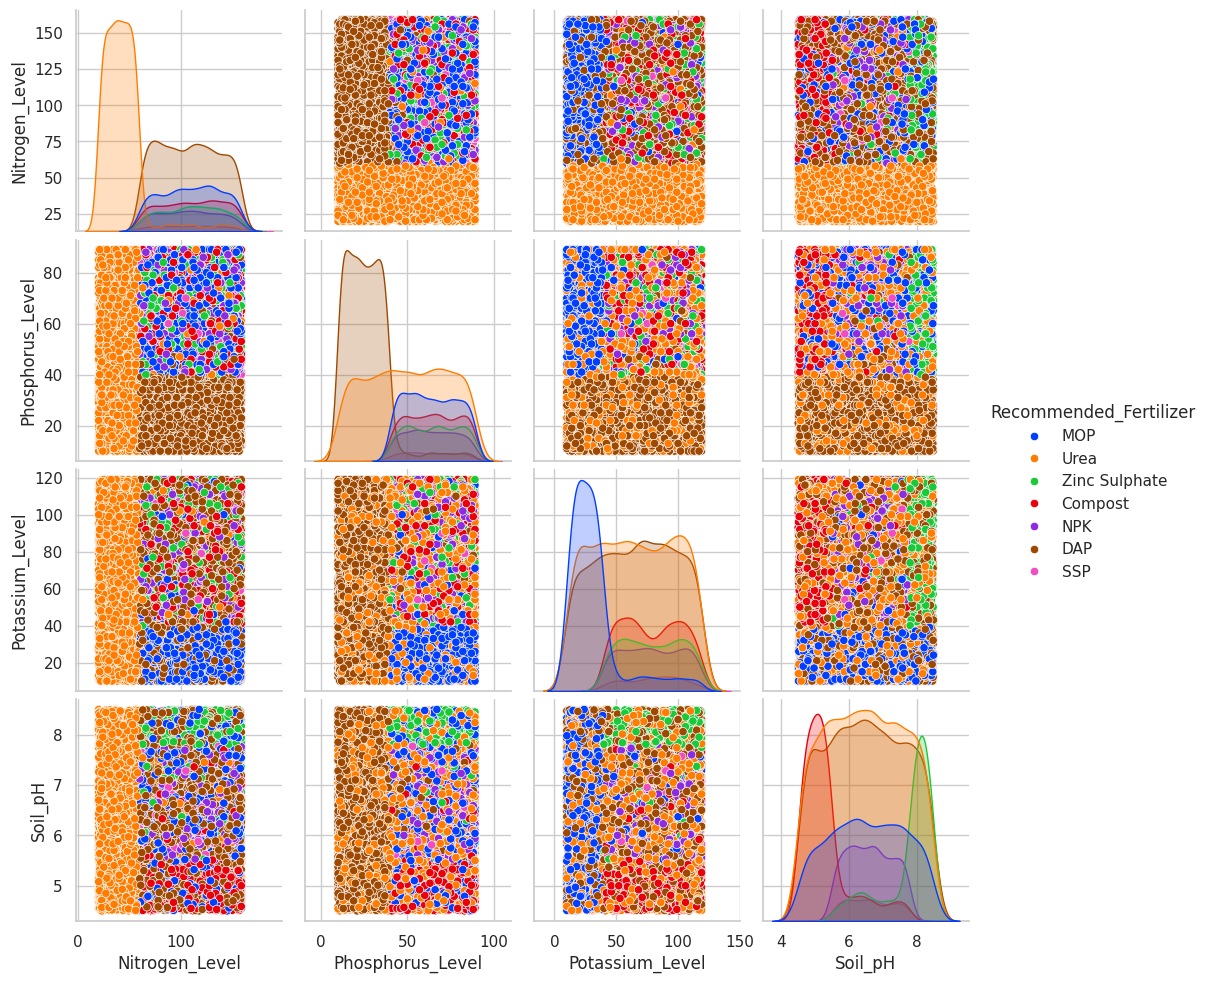

In [9]:
# Analisis mendalam pada NPK dan pH
sns.pairplot(df, vars=['Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Soil_pH'], 
             hue='Recommended_Fertilizer', palette='bright')
plt.show()